# WORKSHOP 1 — Image Processing + PCA

Install libray for Image Processing

In [ ]:
!pip install pillow matplotlib


## Exercise 1 — Image Processing

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

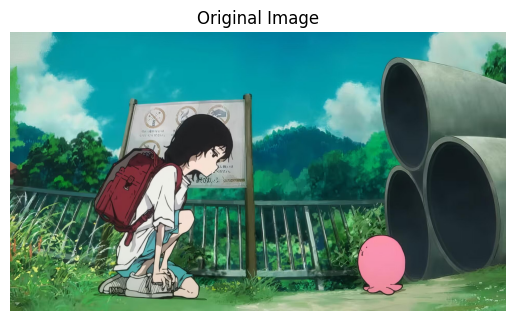

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/AI and Machine Learning/wallpaper.jpg")

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")


Top-left 100×100 pixels

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

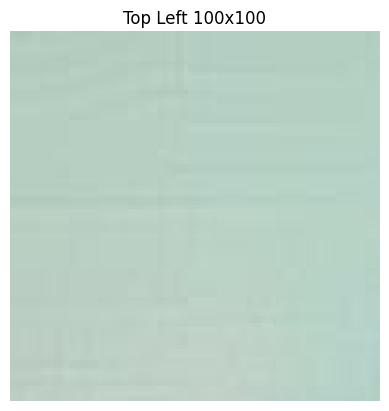

In [ ]:
img_np = np.array(img)

crop = img_np[:100,:100]

plt.imshow(crop)
plt.title("Top Left 100x100")
plt.axis("off")


RGB Channels

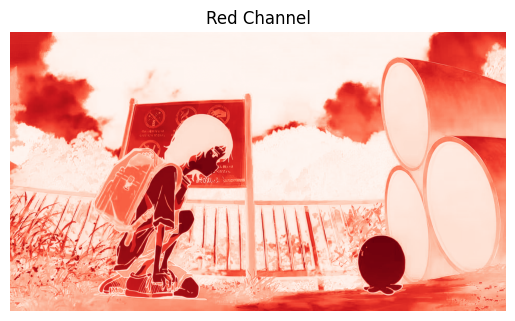

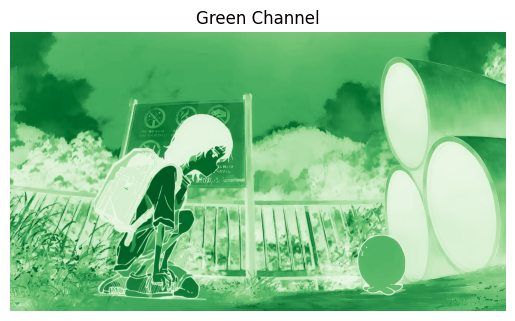

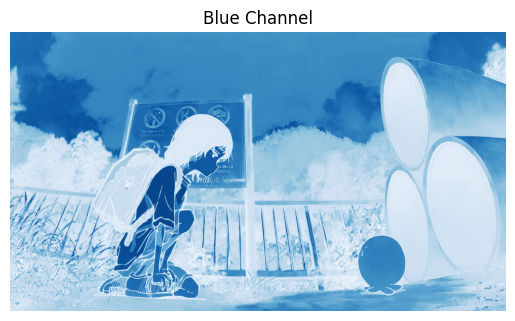

In [ ]:
R = img_np[:,:,0]
G = img_np[:,:,1]
B = img_np[:,:,2]

plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")
plt.show()


Modify Top 100 x 100 pixels

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

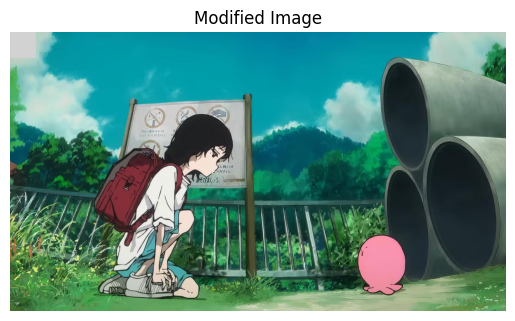

In [ ]:
img_modified = img_np.copy()
img_modified[:100,:100] = 210

plt.imshow(img_modified)
plt.title("Modified Image")
plt.axis("off")


## Exercise 2 — Grayscale Processing

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

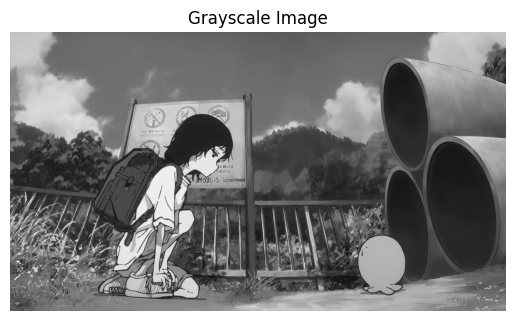

In [12]:
gray = img.convert("L")

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


Middle 150 pixels

(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

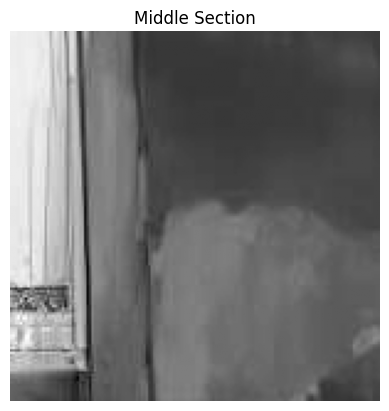

In [13]:
gray_np = np.array(gray)

h, w = gray_np.shape
mid = gray_np[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(mid, cmap="gray")
plt.title("Middle Section")
plt.axis("off")


Threshold

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

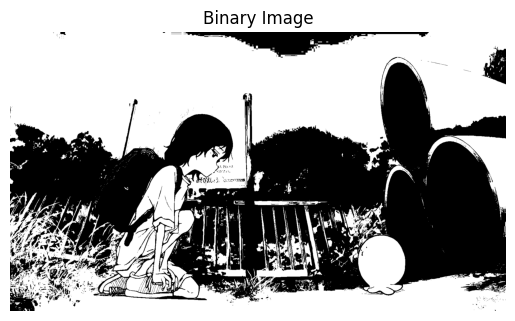

In [14]:
binary = np.where(gray_np < 100, 0, 255)

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")


Rotate Image

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

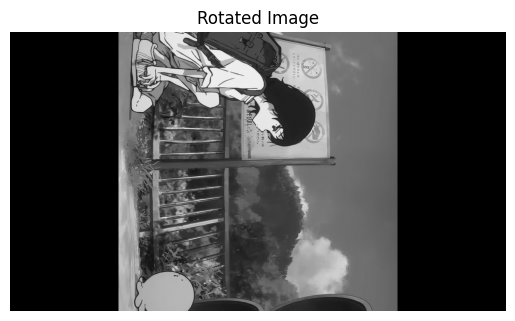

In [15]:
rotated = gray.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")


Convert to RGB

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

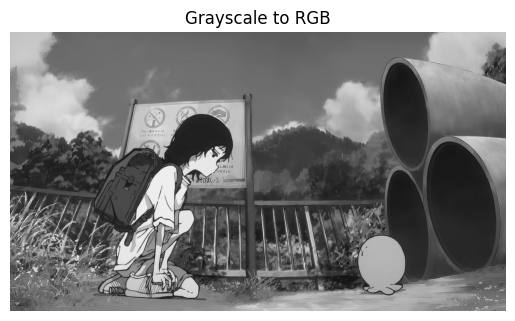

In [ ]:
rgb = np.stack((gray_np,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale to RGB")
plt.axis("off")


## PCA Image Compression (FROM SCRATCH)

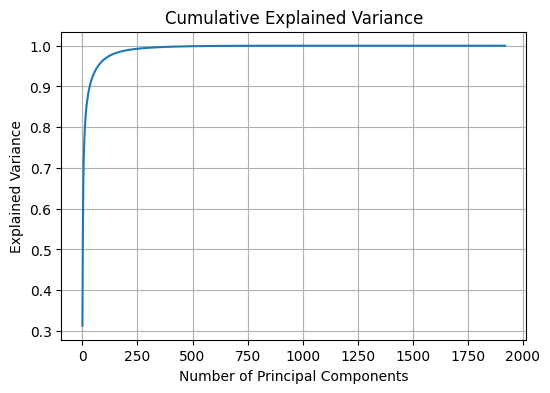

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Use grayscale image
img = gray_np

# Convert image to float
X = img.astype(float)

# Center the data (standardization step)
mean = np.mean(X, axis=0)
X_centered = X - mean

# Compute covariance matrix
cov = np.cov(X_centered, rowvar=False)

# Eigen decomposition (use eigh for symmetric matrices)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Compute cumulative explained variance
cum_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)

# Plot cumulative variance
plt.figure(figsize=(6,4))
plt.plot(cum_var)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance")
plt.grid(True)
plt.show()


Reconstruction

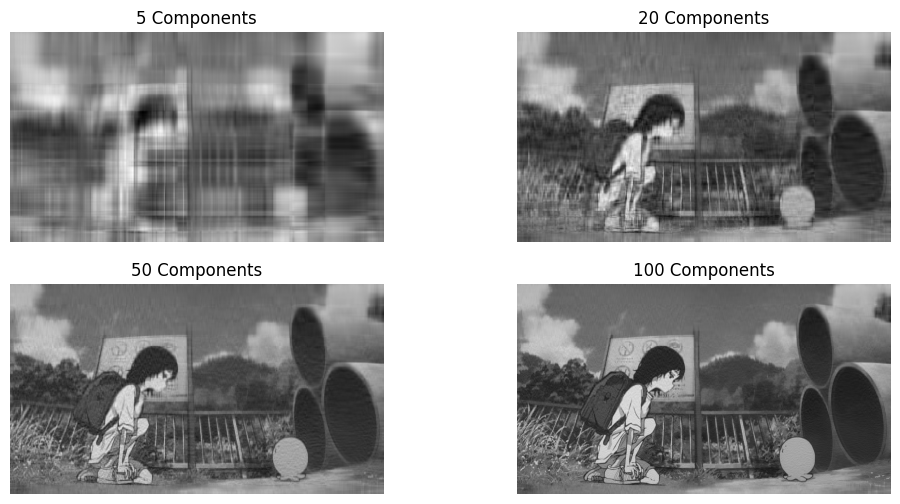

In [ ]:
k_values = [5,20,50,100]

plt.figure(figsize=(12,6))

for i,k in enumerate(k_values):

    pcs = eigenvectors[:,:k]

    compressed = np.dot(X_centered, pcs)
    reconstructed = np.dot(compressed, pcs.T) + mean

    # FIX: remove imaginary part
    reconstructed = np.real(reconstructed)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.show()

